#  We'll do the following tasks:

- **Dataset**: Download and use BDD100k dataset
- **Network**: Define U-Net model using Encoder-Decoder architecture
- **Training**: Train and validate model on the custom dataset
- **Evaluate**: Evaluate the model on Test Data and visualize results

## Imports

In [1]:
!wget https://thinkautonomous-segmentation.s3.eu-west-3.amazonaws.com/segmentation.zip && unzip segmentation.zip && mv segmentation/* .

--2024-12-27 08:50:04--  https://thinkautonomous-segmentation.s3.eu-west-3.amazonaws.com/segmentation.zip
Resolving thinkautonomous-segmentation.s3.eu-west-3.amazonaws.com (thinkautonomous-segmentation.s3.eu-west-3.amazonaws.com)... 3.5.225.114, 52.95.154.60
Connecting to thinkautonomous-segmentation.s3.eu-west-3.amazonaws.com (thinkautonomous-segmentation.s3.eu-west-3.amazonaws.com)|3.5.225.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1340691042 (1.2G) [application/zip]
Saving to: 'segmentation.zip'

segmentation.zip    100%[===================>]   1.25G  23.9MB/s    in 54s     

2024-12-27 08:50:59 (23.5 MB/s) - 'segmentation.zip' saved [1340691042/1340691042]

Archive:  segmentation.zip
   creating: segmentation/
  inflating: __MACOSX/._segmentation  
  inflating: segmentation/.DS_Store  
  inflating: __MACOSX/segmentation/._.DS_Store  
   creating: segmentation/dataset/
  inflating: __MACOSX/segmentation/._dataset  
   creating: segmentation/weights

In [2]:
# basic imports
import random
import numpy as np
from tqdm import tqdm

# DL library imports
import torch
import torch.nn as nn
import torch.nn.functional as F

# libraries for loading image, plotting
import cv2
import matplotlib.pyplot as plt

In [3]:
# try to import the library, if already present
# good to go, else install it and then import library
try:
    import segmentation_models_pytorch as smp
except:
    !pip install segmentation-models-pytorch
    import segmentation_models_pytorch as smp

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.0 MB/s eta 0:00:00:00:01
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16427 sha256=a44b0810fa60695d819c8de113bee1821296d9402edee1db99181d389d2e8ee8
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=1851fd3d6a4b39a764e5d75a6339fd6e822f37140c21b5ac93a8d344807679ec
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-p

## 1. Dataset : Download and use BDD100k dataset

In [4]:
# load images and label data
images = np.load("dataset/image_180_320.npy")[:10000]
labels = np.load("dataset/label_180_320.npy")[:10000]

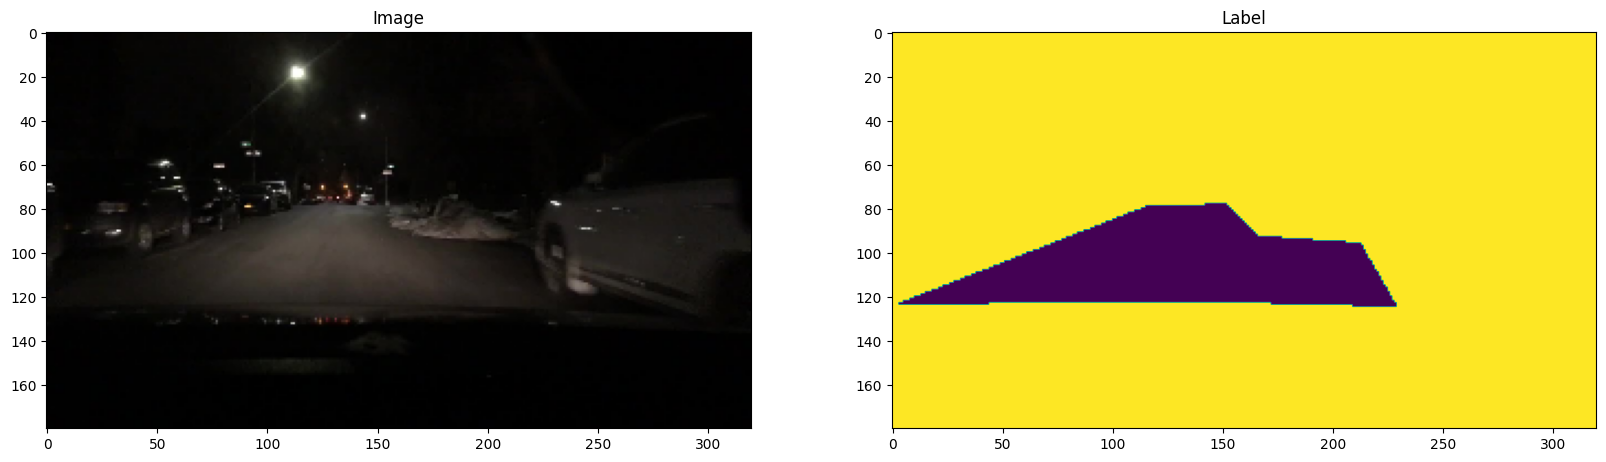

In [5]:
# plot sample image
_, (ax0, ax1) = plt.subplots(1,2, figsize=(20,40))
ax0.imshow(images[458])    # random image number
ax0.set_title("Image")
ax1.imshow(labels[458])
ax1.set_title("Label")
plt.show()

### Class label to standard color maps

- standard color mappings for each class label.
- Helps in readability and consistency across different experimets.
- In our case, we'll define color mappings for the 3 classes - *Current lane, alternate lane and background*

In [6]:
# Constants for Standard color mapping
# reference : https://github.com/bdd100k/bdd100k/blob/master/bdd100k/label/label.py
from collections import namedtuple

# Each label is a tuple with name, class id and color
Label = namedtuple( "Label", [ "name", "train_id", "color"])
drivables = [
             Label("direct", 0, (171, 44, 236)),        # red
             Label("alternative", 1, (86, 211, 19)),  # cyan
             Label("background", 2, (0, 0, 0)),        # black
            ]

train_id_to_color = [c.color for c in drivables if (c.train_id != -1 and c.train_id != 255)]
train_id_to_color = np.array(train_id_to_color)
print(f"train_id_to_color = \n {train_id_to_color}")

train_id_to_color = 
 [[171  44 236]
 [ 86 211  19]
 [  0   0   0]]


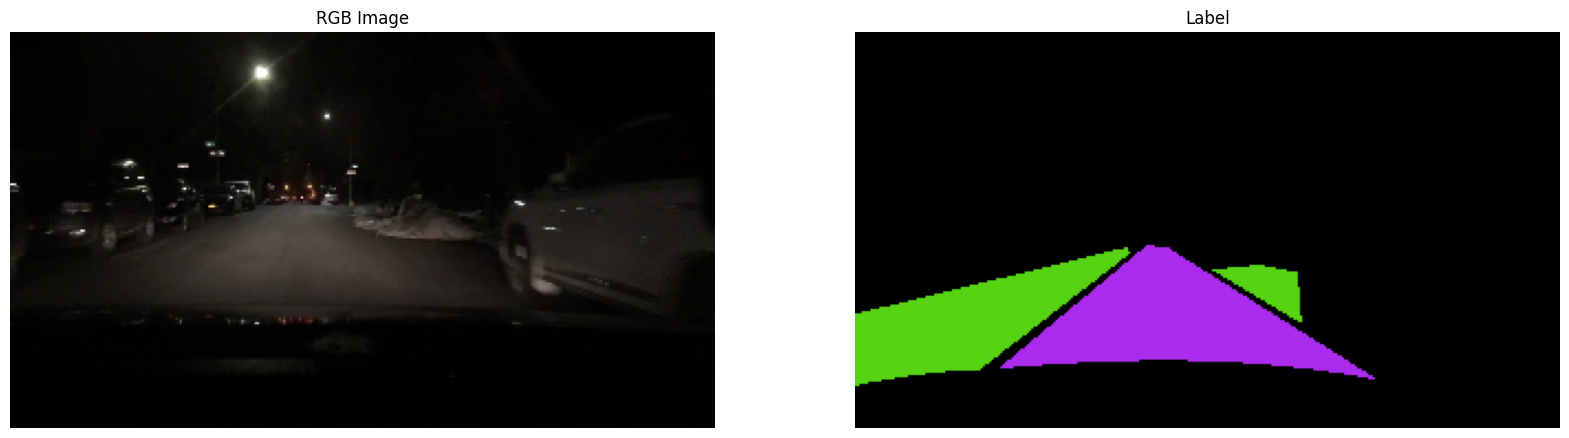

In [7]:
# plot sample image using defined color mappings
fig, axes = plt.subplots(1,2, figsize=(20,10))
axes[0].imshow(images[458]);
axes[0].set_title("RGB Image");
axes[0].axis('off');
axes[1].imshow(train_id_to_color[labels[201]]);
axes[1].set_title("Label");
axes[1].axis('off');

### Build Datasets & DataLoaders
Every PyTorch model is built and train using 3 elements:

*   Dataset
*   DataLoader
*   Model



#### Dataset Class

- We'll define a custom Pytorch Dataset class for BDD100k_dataset drivable / segmentation data.
- The Dataset class should have at least `__len__()` and `__getitem__()` functions

In [8]:
from torch.utils.data import Dataset, DataLoader

class BDD100k_dataset(Dataset):
    def __init__(self, images, labels, tf):
        self.images = images
        self.labels = labels
        self.tf = tf

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, index):
        # read source image and convert to RGB, apply transform
        rgb_image = self.images[index]
        if self.tf is not None:
            rgb_image = self.tf(rgb_image)

        # read label image and convert to torch tensor
        label_image  = torch.from_numpy(self.labels[index]).long()
        return rgb_image, label_image

- Pytorch requires images in torch.Tensor format
- Also, need to normalize images to have zero mean pixel value and standard deviation of 1. **Helps in model learning faster and more robust**
- We'll use *reference mean and standard deviation from Imagenet dataset* in a **pytorch preprocessing transform**

In [9]:
from torchvision import transforms
preprocess = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize(mean=(0.485, 0.56, 0.406), std=(0.229, 0.224, 0.225))
                ])

In [10]:
# Function to split data into train, validation and test sets
def get_datasets(images, labels):
    data = BDD100k_dataset(images, labels, tf=preprocess)
    total_count = len(data)
    train_count = int(0.7 * total_count)
    valid_count = int(0.2 * total_count)
    test_count = total_count - train_count - valid_count
    train_set, val_set, test_set = torch.utils.data.random_split(data,
                (train_count, valid_count, test_count), generator=torch.Generator().manual_seed(1))
    return train_set, val_set, test_set

#### Dataloaders

- Dataloaders help load data in batches
- We'll need to define separate dataloaders for training, validation and test sets



In [11]:
def get_dataloaders(train_set, val_set, test_set):
    train_dataloader = DataLoader(train_set, batch_size=8,drop_last=True)
    val_dataloader   = DataLoader(val_set, batch_size=8)
    test_dataloader  = DataLoader(test_set, batch_size=8)
    return train_dataloader, val_dataloader, test_dataloader


In [12]:
train_set, val_set, test_set= get_datasets(images, labels)
sample_image, sample_label = train_set[0]
print(f"There are {len(train_set)} train images, {len(val_set)} validation images, {len(test_set)} test Images")
print(f"Input shape = {sample_image.shape}, output label shape = {sample_label.shape}")

train_dataloader, val_dataloader, test_dataloader = get_dataloaders(train_set, val_set, test_set)

There are 2401 train images, 686 validation images, 343 test Images
Input shape = torch.Size([3, 180, 320]), output label shape = torch.Size([180, 320])


### Show Sample images from dataset

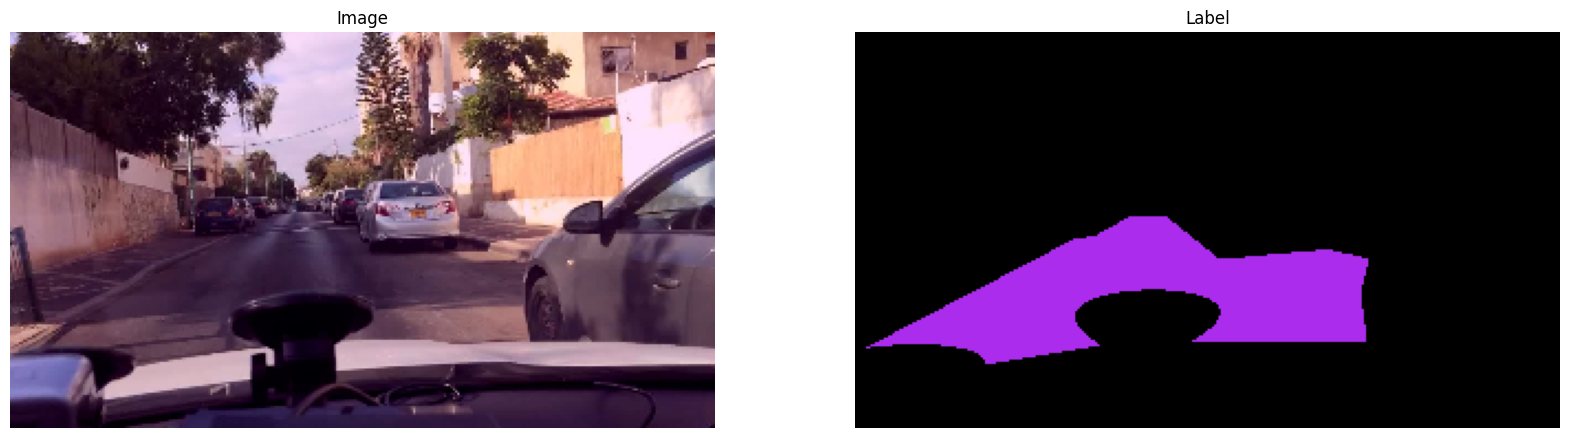

In [13]:
from utils import inverse_transform

rgb_image, label = train_set[np.random.choice(len(train_set))]
rgb_image = inverse_transform(rgb_image).permute(1, 2, 0).cpu().detach().numpy()
label = label.cpu().detach().numpy()

# plot sample image
fig, axes = plt.subplots(1,2, figsize=(20,10))
axes[0].imshow(rgb_image);
axes[0].set_title("Image");
axes[0].axis('off');
axes[1].imshow(train_id_to_color[label]);
axes[1].set_title("Label");
axes[1].axis('off');

## 2. Network: Define a UNet Encoder-Decoder
Pay close attention to the image, this is what we are going to code:
![](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

Notice the 3 main elements:
* The Encoder
* The Decoder
* The Skip-Connections

### The Encoder
Notice how the encoder is made of these "double convolutions".
We have an input image, and then:

*   Two 3x3 Convolutions with ReLU
*   A 2x2 Max Pooling

##### How to create a model with PyTorch
With PyTorch, you always need to have a class with 2 elements:
* An __init__() function, where you define the convolutions, etc...
* A **forward()** function, where you define in which order the elements are going to be called.
<p>


This is one element of the encoder, the other is pooling. So how does that work together?

In [14]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride =1, padding = 1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, stride =1, padding = 1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

In [15]:

class UNetEncoder(nn.Module):
    def __init__(self, in_channels, out_channels, layer_channels):
        super(UNetEncoder, self).__init__()
        self.encoder = nn.ModuleList()

        # Double Convolution
        for num_channels in layer_channels:
            self.encoder.append(double_conv(in_channels, num_channels))
            in_channels = num_channels

        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self):
        # Pass input image through Encoder
        for down in self.encoder:
            x = down(x)
            x = self.pool(x)
        return x

### The Decoder
The upsampling part is made through a series of 4:
* **One Transposed 2x2 Convolution**
* **A Double 3x3 Convolution with ReLU** (as in the encoder)

Finally, the model has **a final 1x1 convolution that classifies every single pixel**!

In [16]:
import torchvision.transforms.functional as TF

class UNetDecoder(nn.Module):
    def __init__(self, layer_channels):
        super(UNetDecoder, self).__init__()
        self.decoder = nn.ModuleList()

        # Decoder layer Double Convolution blocks
        # and upsampling blocks
        self.decoder = nn.ModuleList()
        for num_channels in reversed(layer_channels):
            # upsample output and reduce channels by 2
            self.decoder.append(nn.ConvTranspose2d(num_channels*2, num_channels, kernel_size=2, stride=2))
            self.decoder.append(double_conv(num_channels, num_channels))

    def forward(self, x):
        for up in self.decoder:
            x = up(x)
        return x


### The Final UNet Architecture (with Skip-Connections)


In [17]:
class UNetEncoder(nn.Module):
    def __init__(self, in_channels, layer_channels):
        super(UNetEncoder, self).__init__()
        self.encoder = nn.ModuleList()

        # Double Convolution blocks
        for num_channels in layer_channels:
            self.encoder.append(double_conv(in_channels, num_channels))
            in_channels = num_channels

        # Max Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Pass input image through Encoder blocks
        # and return outputs at each stage
        skip_connections = []
        for down in self.encoder:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        return x, skip_connections


class UNetDecoder(nn.Module):
    def __init__(self, layer_channels):
        super(UNetDecoder, self).__init__()
        self.decoder = nn.ModuleList()

        # Decoder layer Double Convolution blocks
        # and upsampling blocks
        self.decoder = nn.ModuleList()
        for num_channels in reversed(layer_channels):
            self.decoder.append(nn.ConvTranspose2d(num_channels*2, num_channels, kernel_size=2, stride=2))
            self.decoder.append(double_conv(num_channels*2, num_channels))


    def forward(self, x, skip_connections):
        for idx in range(0, len(self.decoder), 2):
            # upsample output and reduce channels by 2
            x = self.decoder[idx](x)

            # if skip connection shape doesn't match, resize
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])

            # concatenate and pass through double_conv block
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx+1](concat_skip)
        return x



class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, layer_channels):
        super(UNet, self).__init__()

        # Encoder and decoder modules
        self.encoder = UNetEncoder(in_channels, layer_channels)
        self.decoder = UNetDecoder(layer_channels)

        # conv layer to transition from encoder to decoder and
        # 1x1 convolution to reduce num channels to out_channels
        self.bottleneck = double_conv(layer_channels[-1], layer_channels[-1]*2)
        self.final_conv = nn.Conv2d(layer_channels[0], out_channels, kernel_size=1)

        # initialize parameters now to avoid modifying the initialization of top_blocks
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, a=1)
                # nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Encoder blocks
        encoder_output, skip_connections = self.encoder(x)

        # transition between encoder and decoder
        x = self.bottleneck(encoder_output)

        # we need the last skip connection first
        # so reversing the list
        skip_connections = skip_connections[::-1]

        # Decoder blocks
        x = self.decoder(x, skip_connections)

        # final 1x1 conv to match input size
        return self.final_conv(x)

## 3. Training : Train and validate model on the custom dataset

In [18]:
from utils import meanIoU                  # metric class
from utils import plot_training_results    # function to plot training curves
from utils import evaluate_model           # evaluation function
from utils import train_validate_model     # train validate function

### Hyperparameters

In [19]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

# reference : https://smp.readthedocs.io/en/latest/losses.html
criterion = smp.losses.DiceLoss('multiclass', classes=[0,1,2], log_loss = True, smooth=1.0)

# MODEL HYPERPARAMETERS
N_EPOCHS = 50
NUM_CLASSES = 3
MAX_LR = 3e-4
MODEL_NAME = 'UNet_baseline'

# create model, optimizer, lr_scheduler and pass to training function
model = UNet(in_channels=3, out_channels=3, layer_channels=[64, 128, 256, 512]).to(device)
optimizer = optim.Adam(model.parameters(), lr=MAX_LR)
scheduler = OneCycleLR(optimizer, max_lr= MAX_LR, epochs = N_EPOCHS,steps_per_epoch = len(train_dataloader),
                       pct_start=0.3, div_factor=10, anneal_strategy='cos')

In [20]:
output_path = "dataset"

Starting 1 epoch ...


100%|██████████| 86/86 [00:14<00:00,  6.07it/s]


Epoch: 1, trainLoss:1.06135, validationLoss:0.76310, meanIoU: 0.51
Starting 2 epoch ...


100%|██████████| 86/86 [00:14<00:00,  6.02it/s]


Epoch: 2, trainLoss:0.66495, validationLoss:0.63610, meanIoU: 0.55
Starting 3 epoch ...


...

Epoch: 48, trainLoss:0.04355, validationLoss:0.24538, meanIoU: 0.71
Starting 49 epoch ...


100%|██████████| 86/86 [00:13<00:00,  6.15it/s]


Epoch: 49, trainLoss:0.04318, validationLoss:0.24502, meanIoU: 0.71
Starting 50 epoch ...


100%|██████████| 86/86 [00:13<00:00,  6.17it/s]


Epoch: 50, trainLoss:0.04297, validationLoss:0.24540, meanIoU: 0.71


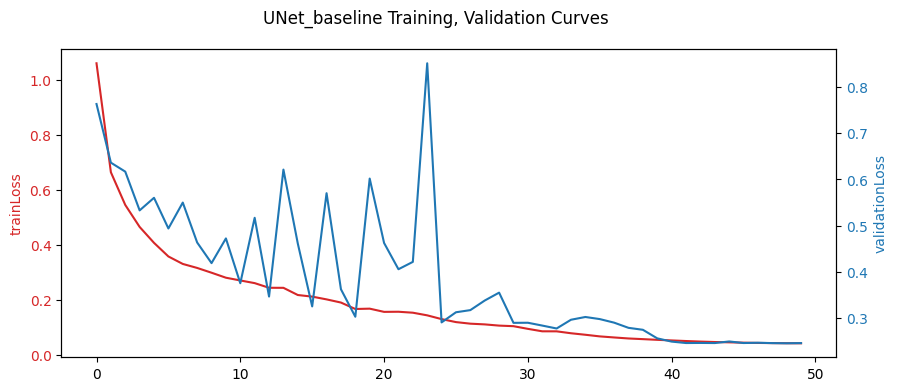

In [21]:
_ = train_validate_model(model, N_EPOCHS, MODEL_NAME, criterion, optimizer,
                         device, train_dataloader, val_dataloader, meanIoU, 'meanIoU',
                         NUM_CLASSES, lr_scheduler = scheduler, output_path = output_path)

# 4. Evaluate : Evaluate the model on Test Data and visualize results

In [22]:
#model.load_state_dict(torch.load(f'{output_path}/{MODEL_NAME}.pt', map_location=device))
#_, test_metric = evaluate_model(model, test_dataloader, criterion, meanIoU, NUM_CLASSES, device)
#print(f"\nModel has {test_metric} mean IoU in test set")

In [23]:
model.load_state_dict(torch.load(f'{output_path}/{MODEL_NAME}.pt', map_location=device))

_, test_metric_iou = evaluate_model(model, test_dataloader, criterion, meanIoU, NUM_CLASSES, device)
print(f"\nModel has {test_metric_iou} mean IoU in test set")

correct_pixels = 0
total_pixels = 0

model.eval()  
for inputs, labels in test_dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)  
    
    correct_pixels += (preds == labels).sum().item()
    total_pixels += labels.numel()

pixel_accuracy_value = correct_pixels / total_pixels
print(f"Model has {pixel_accuracy_value * 100:.2f}% Pixel Accuracy in test set")


/tmp/ipykernel_23/3226295882.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{output_path}/{MODEL_NAME}.pt', map_location=device))
100


Model has 0.7228393320403256 mean IoU in test set
Model has 94.49% Pixel Accuracy in test set


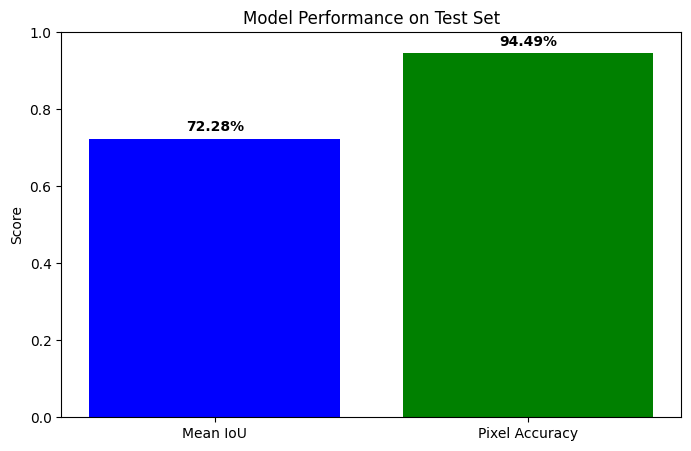

In [27]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Mean IoU", "Pixel Accuracy"]
values = [0.7228393320403256, 0.9449]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance on Test Set')

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center', fontweight='bold')

plt.show()


In [25]:
from utils import visualize_predictions

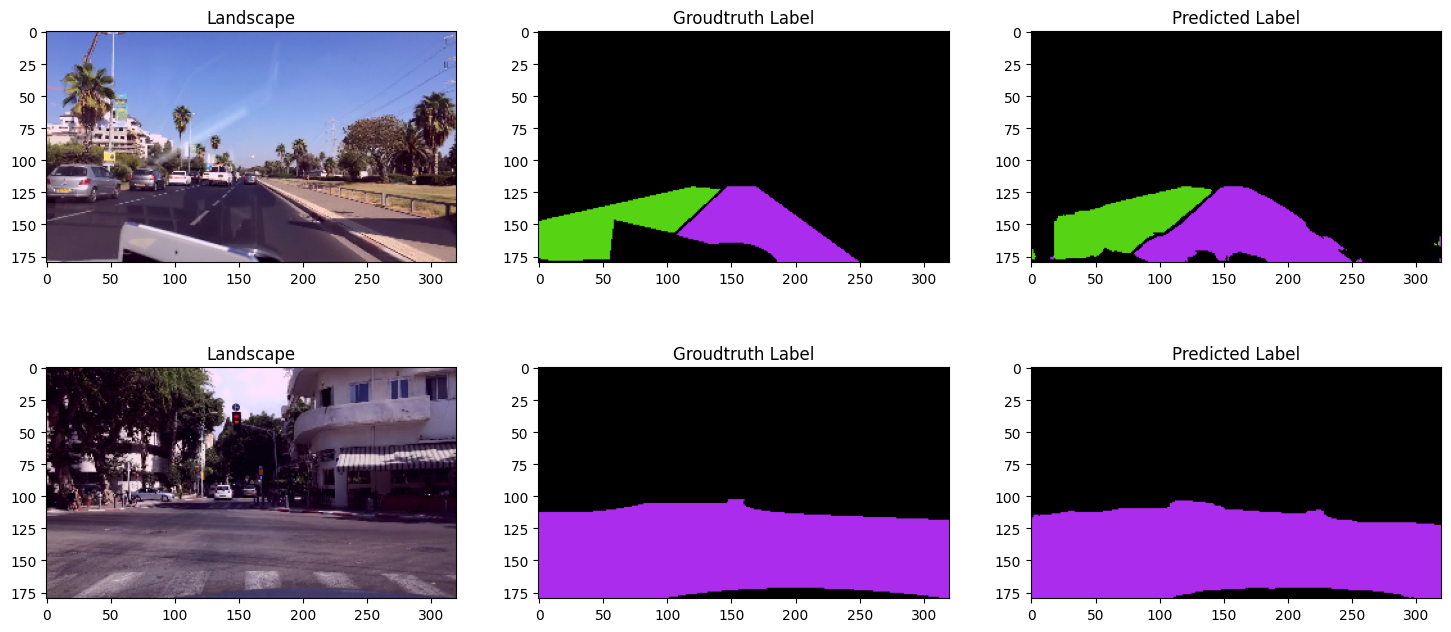

In [30]:
num_test_samples = 2
_, axes = plt.subplots(num_test_samples, 3, figsize=(3*6, num_test_samples * 4))
visualize_predictions(model, test_set, axes, device, numTestSamples=num_test_samples, id_to_color=train_id_to_color)